This notebook demonstrates:

- Pulling real market option data (Yahoo Finance)
- Pricing options using Black–Scholes
- Computing implied volatility
- Studying volatility smile behaviour



In [1]:
import sys
import os

# Add project root to path
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from models.black_scholes import bs_call_price, bs_put_price
from models.implied_vol import implied_vol_call, implied_vol_put
from data.market_data import get_stock_price, get_option_chain

In [4]:
ticker = "AAPL" #Apple
expiry = "2026-05-15"

S0 = get_stock_price(ticker)
calls, puts = get_option_chain(ticker, expiry)

print("Spot price:", S0)
calls.head()
calls.columns


c:\Users\bryan\Documents\ProjectsPython\risk_hedging\data\market_data.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(data["Close"].iloc[-1])


Spot price: 275.5


Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask',
       'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency'],
      dtype='object')

In [5]:
# Pick one call option near ATM, i.e. the striker price closest to S0
option = calls.iloc[(calls["strike"] - S0).abs().argmin()]

K = option["strike"]
market_price = option["lastPrice"]
T = (pd.to_datetime(expiry) - pd.Timestamp.today()).days / 365.0
r = 0.05

K, market_price


(np.float64(275.0), np.float64(15.9))

In [6]:
iv = implied_vol_call(
    market_price=market_price,
    S=S0,
    K=K,
    T=T,
    r=r
)

model_price = bs_call_price(S0, K, T, r, iv)

pd.DataFrame({
    "Market Price": [market_price],
    "Model Price": [model_price],
    "Implied Vol": [iv]
})


,Market Price,Model Price,Implied Vol
0,15.9,15.9,0.254517


In [7]:
ivs = []

for _, row in calls.iterrows():
    try:
        market_price = 0.5 * (row["bid"] + row["ask"])
        if market_price <= 0 or T <= 0:
            raise ValueError

        iv = implied_vol_call(
            market_price=market_price,
            S=S0,
            K=row["strike"],
            T=T,
            r=r
        )
        ivs.append(iv)

    except:
        ivs.append(np.nan)

calls["implied_vol"] = ivs
print(ivs)

[3.666443252461672, nan, nan, nan, nan, 1.7598649344620938, 1.634122459024538, 1.5240649813496683, 1.4261783012863285, 1.2577010050064823, 1.0019726325018399, 0.8630204889735381, 0.9361254248681858, nan, nan, nan, 0.7060501921706461, 0.792728379420913, nan, nan, nan, 0.5747633537360565, nan, nan, 0.5597637071966722, 0.546630210027595, 0.5317483327177003, 0.45810554844967477, 0.487051082077296, 0.3693852580450078, 0.4537492708001256, 0.44044278862172614, 0.39176204374676915, 0.3888623641882469, 0.37139705587082456, 0.3978576167661489, 0.3540004839721377, 0.3488450514894713, 0.3258753805065158, 0.3165063565472465, 0.32039703713357987, 0.3059019675537493, 0.29770920596437644, 0.2915044467402332, 0.2868141246403043, 0.2800073696559912, 0.27417265566239346, 0.2674996499450276, 0.262248002706446, 0.25679447388822013, 0.25220399684079, 0.24722852253812455, 0.24306295734897443, 0.23966926951386816, 0.2372259446546218, 0.23458551962620258, 0.23270657186844154, 0.23177781024750516, 0.23039520252

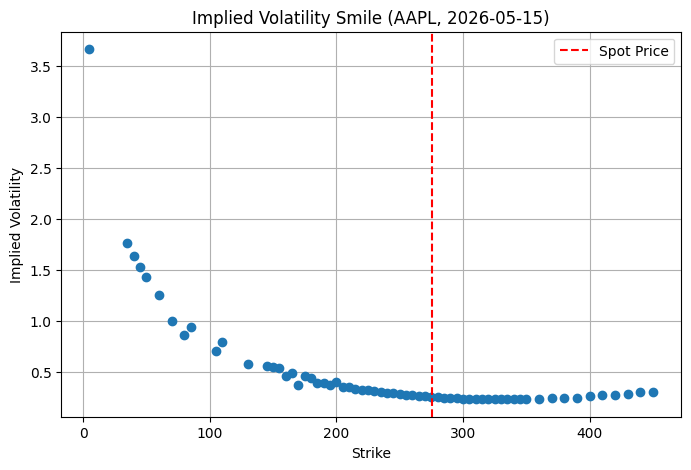

In [8]:
plt.figure(figsize=(8,5))
plt.plot(calls["strike"], calls["implied_vol"], marker="o", linestyle="")
plt.axvline(S0, color="red", linestyle="--", label="Spot Price")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(f"Implied Volatility Smile ({ticker}, {expiry})")
plt.legend()
plt.grid(True)
plt.show()


## Observations

- Implied volatility varies by strike (volatility smile)
- ATM options have the most stable implied volatility
- Model prices closely match market prices when using implied vol

This validates the Black–Scholes model as a pricing *framework*,
with market-implied volatility encoding risk perception.


In [8]:
from models.monte_carlo import mc_european_call

mc_price, mc_err = mc_european_call(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=iv
)

mc_price, mc_err


ModuleNotFoundError: No module named 'models.monte_carlo'